In [25]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [26]:
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
print("Total dataset size:", len(mnist))


Total dataset size: 60000


In [27]:

all_features = np.arange(len(mnist))
all_labels = mnist.targets.numpy()

train_features, remaining_features, train_labels, remaining_labels = train_test_split(
    all_features, all_labels,
    train_size=0.6,
    stratify=all_labels,
    random_state=0
)

val_features, test_features, val_labels, test_labels = train_test_split(
    remaining_features, remaining_labels,
    train_size=0.5,
    stratify=remaining_labels,
    random_state=0
)

print(f"Train: {len(train_features)} Val: {len(val_features)} Test sizes: {len(test_features)}")


Train: 36000 Val: 12000 Test sizes: 12000


In [36]:


# Create Subsets using the split indices
train_dataset = Subset(mnist, train_features)
val_dataset   = Subset(mnist, val_features)
test_dataset  = Subset(mnist, test_features)

# Create DataLoaders for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Quick check of one batch
X_batch, y_batch = next(iter(train_loader))
print("Batch shapes:", X_batch.shape, y_batch.shape)
print("Pixel range:", X_batch.min().item(), "→", X_batch.max().item())


Batch shapes: torch.Size([64, 1, 28, 28]) torch.Size([64])
Pixel range: 0.0 → 1.0


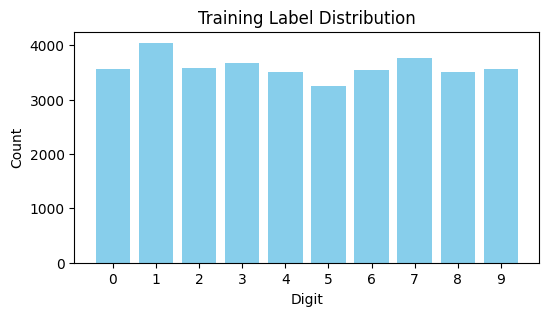

In [29]:
# Count label frequencies in each split
train_labels = np.array(mnist.targets)[train_features]
val_labels = np.array(mnist.targets)[val_features]
test_labels = np.array(mnist.targets)[test_features]

# Plot for training set
plt.figure(figsize=(6,3))
plt.bar(*zip(*sorted(Counter(train_labels).items())), color='skyblue')
plt.title("Training Label Distribution")
plt.xlabel("Digit"); plt.ylabel("Count")
plt.xticks(range(10))
plt.show()


In [30]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden1=128, hidden2=64, output_size=10):
        super(MLP, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        self.relu = nn.ReLU()

        # Initialize weights (He initialization)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc3.weight)

        # Initialize biases to zero
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x):
        # Flatten image: (batch, 1, 28, 28) → (batch, 784)
        x = x.view(x.size(0), -1)
        # Pass through layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # output layer (no activation here)
        return x


In [31]:
model = MLP().to(device)
print(model)


MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [32]:
import os, time
import torch
import torch.nn as nn
import torch.optim as optim

# Hyperparameters
num_epochs = 20          # change if you want longer training
lr = 0.01                # SGD lr used in assignment baseline
momentum = 0.0           # change to 0.9 if you want momentum
weight_decay = 0.0       # L2 regularization (set >0 if needed)
batch_size = 64          # already used in your DataLoaders

# Criterion + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

# Checkpoint path
os.makedirs("checkpoints", exist_ok=True)
best_ckpt_path = "checkpoints/best_mlp.pth"

# Early stopping params (optional)
early_stop = True
patience = 5   # stop if val loss doesn't improve for `patience` epochs

print("Training config → epochs:", num_epochs, "lr:", lr, "device:", device)


Training config → epochs: 20 lr: 0.01 device: cuda


In [33]:
best_val_loss = float('inf')
best_epoch = -1
no_improve = 0

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [],   "val_acc": []
}

t0 = time.time()
for epoch in range(1, num_epochs + 1):
    # ---------- Train ----------
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)                 # logits
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += X.size(0)

    epoch_train_loss = running_loss / running_total
    epoch_train_acc  = running_correct / running_total

    # ---------- Validate ----------
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            Xv, yv = Xv.to(device), yv.to(device)
            outputs_v = model(Xv)
            loss_v = criterion(outputs_v, yv)
            val_running_loss += loss_v.item() * Xv.size(0)
            preds_v = outputs_v.argmax(dim=1)
            val_running_correct += (preds_v == yv).sum().item()
            val_running_total += Xv.size(0)

    epoch_val_loss = val_running_loss / val_running_total
    epoch_val_acc  = val_running_correct / val_running_total

    # Save history
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    # Checkpoint on improvement (lower val loss)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": epoch_val_loss,
            "val_acc": epoch_val_acc
        }, best_ckpt_path)
        improved_str = " (improved → saved)"
    else:
        no_improve += 1
        improved_str = ""

    elapsed = time.time() - t0
    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Train loss: {epoch_train_loss:.4f}, Train acc: {epoch_train_acc:.4f} | "
          f"Val loss: {epoch_val_loss:.4f}, Val acc: {epoch_val_acc:.4f} | "
          f"Elapsed: {elapsed/60:.2f} min{improved_str}")

    # Early stopping
    if early_stop and no_improve >= patience:
        print(f"Early stopping after {epoch} epochs (no val loss improvement for {patience} epochs).")
        break

print(f"Best val loss {best_val_loss:.4f} at epoch {best_epoch}")


Epoch  1/20 | Train loss: 1.1064, Train acc: 0.7150 | Val loss: 0.5346, Val acc: 0.8602 | Elapsed: 0.11 min (improved → saved)
Epoch  2/20 | Train loss: 0.4551, Train acc: 0.8761 | Val loss: 0.3775, Val acc: 0.8948 | Elapsed: 0.20 min (improved → saved)
Epoch  3/20 | Train loss: 0.3623, Train acc: 0.8962 | Val loss: 0.3229, Val acc: 0.9085 | Elapsed: 0.30 min (improved → saved)
Epoch  4/20 | Train loss: 0.3188, Train acc: 0.9087 | Val loss: 0.2916, Val acc: 0.9167 | Elapsed: 0.39 min (improved → saved)
Epoch  5/20 | Train loss: 0.2903, Train acc: 0.9159 | Val loss: 0.2699, Val acc: 0.9220 | Elapsed: 0.49 min (improved → saved)
Epoch  6/20 | Train loss: 0.2685, Train acc: 0.9228 | Val loss: 0.2543, Val acc: 0.9278 | Elapsed: 0.58 min (improved → saved)
Epoch  7/20 | Train loss: 0.2509, Train acc: 0.9276 | Val loss: 0.2381, Val acc: 0.9340 | Elapsed: 0.69 min (improved → saved)
Epoch  8/20 | Train loss: 0.2361, Train acc: 0.9324 | Val loss: 0.2307, Val acc: 0.9338 | Elapsed: 0.78 min (im

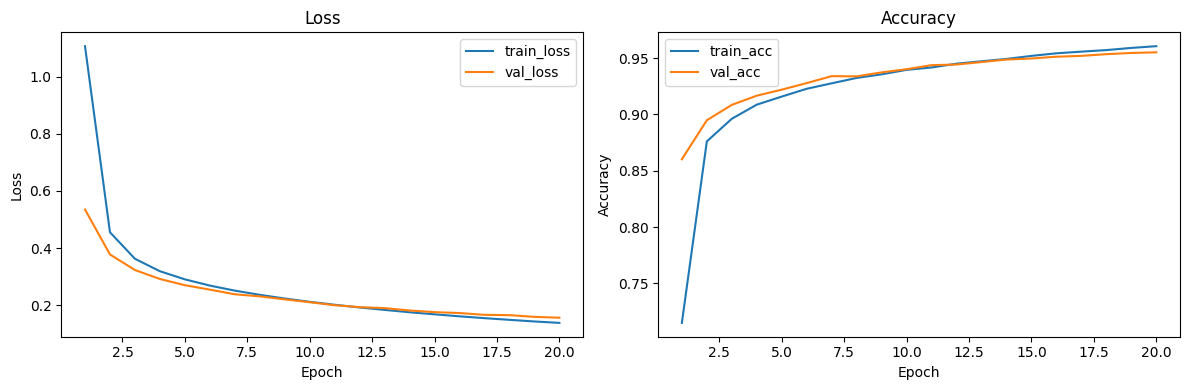

In [34]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()

plt.tight_layout(); plt.show()


Test accuracy: 0.9526
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1185
           1       0.98      0.98      0.98      1348
           2       0.96      0.94      0.95      1191
           3       0.96      0.92      0.94      1226
           4       0.94      0.95      0.95      1169
           5       0.93      0.95      0.94      1085
           6       0.96      0.97      0.97      1183
           7       0.97      0.96      0.96      1253
           8       0.94      0.94      0.94      1170
           9       0.92      0.94      0.93      1190

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



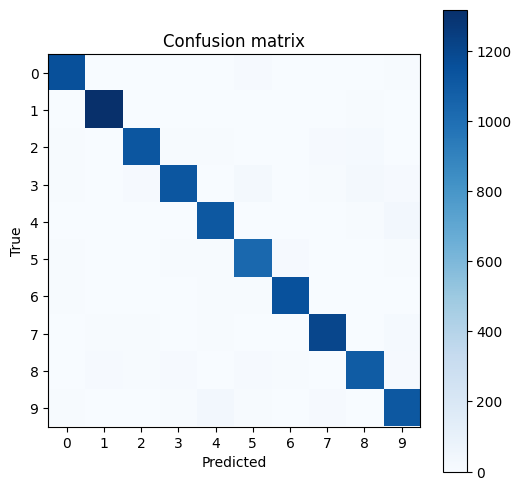

In [35]:
# Load best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for Xt, yt in test_loader:
        Xt, yt = Xt.to(device), yt.to(device)
        logits = model(Xt)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(yt.cpu())

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.concatenate([p.numpy() for p in all_preds])
y_true = np.concatenate([t.numpy() for t in all_targets])

test_acc = (y_pred == y_true).mean()
print(f"Test accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("Classification report:\n", classification_report(y_true, y_pred))

# Simple confusion matrix plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(10)); plt.yticks(range(10))
plt.show()
